# 02_entropy_conditional_tree_codes.ipynb

本 notebook 生成第 2 篇推文所需的插图和示例数据。

输出文件：

- `./figs/entropy_cond_fig01_weather_groups.png`
- `./figs/entropy_cond_fig02_information_gain.png`
- `./figs/entropy_cond_fig03_tree_split.png`
- `./data/entropy_cond_weather_example.csv`
- `./data/entropy_cond_split_example.csv`


In [15]:
import os
from pathlib import Path
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

# 创建输出文件夹：figs 存放插图，data 存放模拟数据或示例数据
FIG_DIR = Path('./figs')
DATA_DIR = Path('./data')
FIG_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

# ── Matplotlib 中文字体与通用样式 ──────────────────────────────
# Windows 本地优先使用 SimHei；Linux/macOS 环境下尝试注册 Noto CJK 字体文件。
# 注意：标题中的 log_2 不使用 Unicode 下标，而使用 mathtext，避免出现底数乱码。
import matplotlib.font_manager as fm

if platform.system() == 'Windows':
    FONT_FAMILY = 'SimHei'
else:
    font_candidates = [
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc',
        '/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
        '/System/Library/Fonts/PingFang.ttc',
    ]
    FONT_FAMILY = 'DejaVu Sans'
    for font_path in font_candidates:
        if Path(font_path).exists():
            fm.fontManager.addfont(font_path)
            FONT_FAMILY = fm.FontProperties(fname=font_path).get_name()
            break

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [FONT_FAMILY, 'SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 240,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
})

# 统一色板。为了便于后续维护，所有图片尽量使用同一组颜色。
COLORS = {
    'blue':   '#2C7FB8',
    'green':  '#41AB5D',
    'orange': '#F28E2B',
    'red':    '#D95F5F',
    'purple': '#7B6FD6',
    'gray':   '#666666',
    'light':  '#F5F7FA',
    'dark':   '#263238',
}

def savefig(name, tight=True):
    """统一保存图片，避免每个代码块重复写路径。"""
    path = FIG_DIR / name
    if tight:
        plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    print(f'已保存: {path}')


In [20]:
def entropy(prob):
    """离散概率分布的 Shannon entropy。"""
    prob = np.asarray(prob, dtype=float)
    prob = prob[prob > 0]
    return -np.sum(prob * np.log2(prob))

# 气温区间示例：X 为是否下雨，Y 为气温区间。
weather = pd.DataFrame({
    'group': ['低温区', '中温区', '高温区'],
    'P(Y)': [0.30, 0.40, 0.30],
    'P(rain|Y)': [0.05, 0.40, 0.75],
})
weather['P(no rain|Y)'] = 1 - weather['P(rain|Y)']
weather['H(X|Y=y)'] = weather.apply(lambda r: entropy([r['P(rain|Y)'], r['P(no rain|Y)']]), axis=1)
weather.to_csv(DATA_DIR / 'entropy_cond_weather_example.csv', index=False, encoding='utf-8-sig')

H_cond = np.sum(weather['P(Y)'] * weather['H(X|Y=y)'])
p_rain = np.sum(weather['P(Y)'] * weather['P(rain|Y)'])
H_total = entropy([p_rain, 1 - p_rain])
IG = H_total - H_cond
print(weather)
print('-' * 40)
print(f'H(X)   = {H_total:.3f}')
print(f'H(X|Y) = {H_cond:.3f}')
print(f'IG     = {IG:.3f}')


  group  P(Y)  P(rain|Y)  P(no rain|Y)  H(X|Y=y)
0   低温区   0.3       0.05          0.95  0.286397
1   中温区   0.4       0.40          0.60  0.970951
2   高温区   0.3       0.75          0.25  0.811278
----------------------------------------
H(X)   = 0.971
H(X|Y) = 0.718
IG     = 0.253


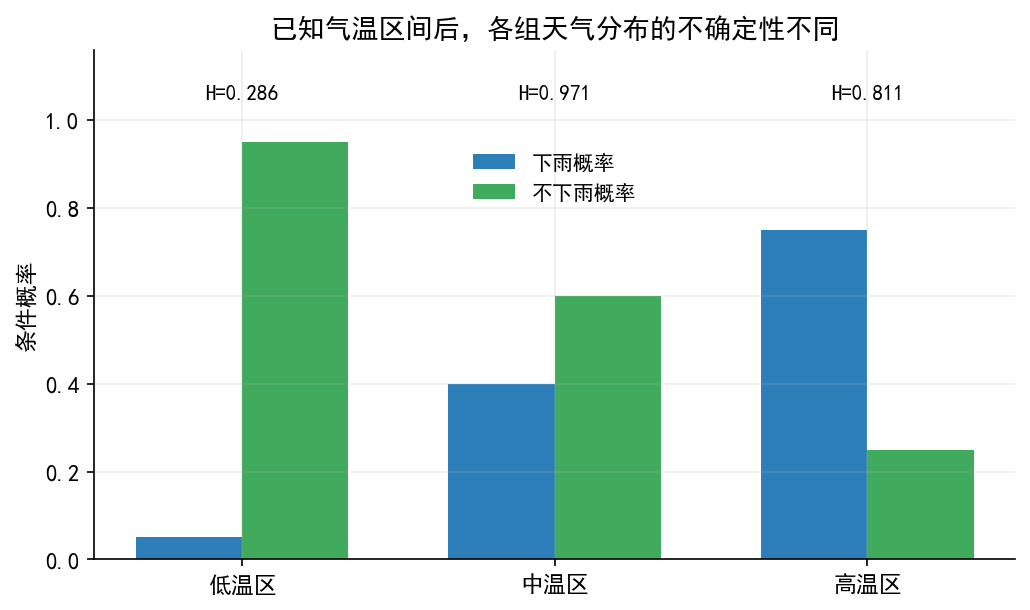

已保存: figs\entropy_cond_fig01_weather_groups.png


In [23]:
# 图 1：不同气温区间下，下雨概率与局部熵不同。
fig, ax = plt.subplots(figsize=(7.0, 4.2))
x = np.arange(len(weather))
width = 0.34

ax.bar(x - width/2, weather['P(rain|Y)'], width, color=COLORS['blue'], label='下雨概率')
ax.bar(x + width/2, weather['P(no rain|Y)'], width, color=COLORS['green'], label='不下雨概率')

for i, row in weather.iterrows():
    ax.text(i, 1.04, f"H={row['H(X|Y=y)']:.3f}", ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(weather['group'])
ax.set_ylim(0, 1.16)
ax.set_ylabel('条件概率')
ax.set_title('已知气温区间后，各组天气分布的不确定性不同')
ax.legend(
    loc='center',
    bbox_to_anchor=(1, 0.87),
    bbox_transform=ax.transData,
    frameon=False,
    ncol=1
)
savefig('entropy_cond_fig01_weather_groups.png')


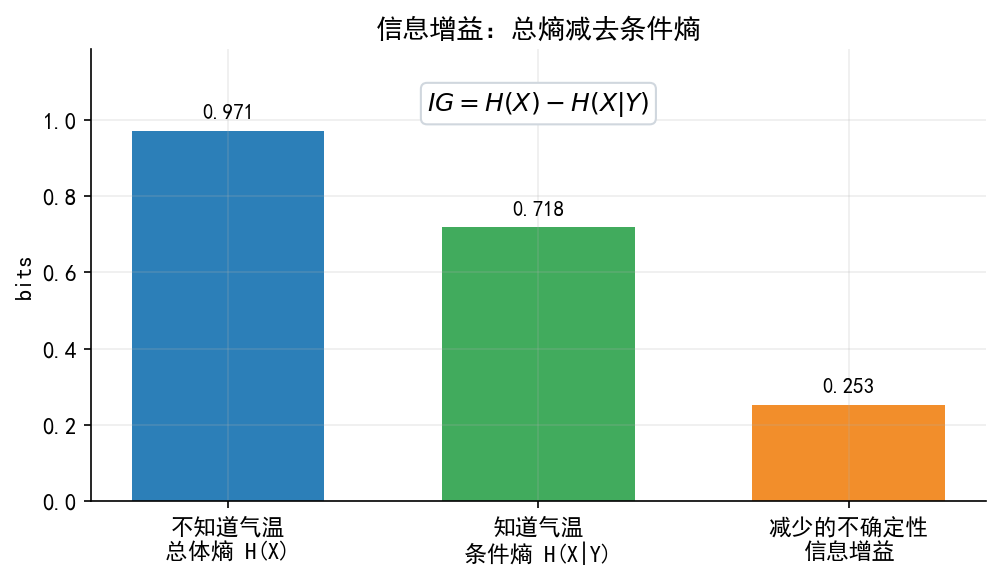

已保存: figs\entropy_cond_fig02_information_gain.png


In [18]:
# 图 2：信息增益 = 总体熵 - 条件熵。
fig, ax = plt.subplots(figsize=(6.8, 4.0))
labels = ['不知道气温\n总体熵 H(X)', '知道气温\n条件熵 H(X|Y)', '减少的不确定性\n信息增益']
values = [H_total, H_cond, IG]
colors = [COLORS['blue'], COLORS['green'], COLORS['orange']]

bars = ax.bar(labels, values, color=colors, width=0.62)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.025, f'{val:.3f}',
            ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, max(values) * 1.22)
ax.set_ylabel('bits')
ax.set_title('信息增益：总熵减去条件熵')
ax.text(0.50, 0.88, r'$IG=H(X)-H(X|Y)$', transform=ax.transAxes,
        ha='center', va='center', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#D0D7DE'))
savefig('entropy_cond_fig02_information_gain.png')


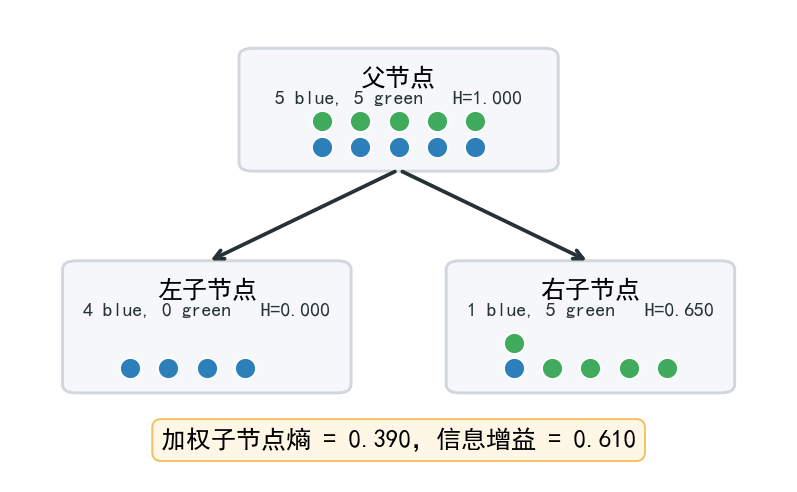

已保存: figs\entropy_cond_fig03_tree_split.png


In [25]:
# 图 3：更紧凑的决策树 split 示意图。
# 该图用彩色圆点表示类别分布，用卡片表示父节点和子节点。
# 蓝点和绿点越混杂，节点熵越高；分裂后子节点越纯，信息增益越大。

split = pd.DataFrame({
    'node': ['parent', 'left', 'right'],
    'blue': [5, 4, 1],
    'green': [5, 0, 5],
})
split['n'] = split['blue'] + split['green']
split['H'] = split.apply(lambda r: entropy([r['blue']/r['n'], r['green']/r['n']]), axis=1)
weighted_child_entropy = (split.loc[1, 'n']/split.loc[0, 'n']) * split.loc[1, 'H'] + \
                         (split.loc[2, 'n']/split.loc[0, 'n']) * split.loc[2, 'H']
info_gain = split.loc[0, 'H'] - weighted_child_entropy
split.to_csv(DATA_DIR / 'entropy_cond_split_example.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# 卡片位置：(x, y, w, h)
cards = {
    'parent': (0.31, 0.68, 0.38, 0.23),
    'left':   (0.08, 0.20, 0.34, 0.25),
    'right':  (0.58, 0.20, 0.34, 0.25),
}

node_info = {
    'parent': ('父节点', 5, 5, split.loc[0, 'H']),
    'left':   ('左子节点', 4, 0, split.loc[1, 'H']),
    'right':  ('右子节点', 1, 5, split.loc[2, 'H']),
}

def draw_card(ax, key):
    x0, y0, w, h = cards[key]
    title, nb, ng, H = node_info[key]
    # 背景卡片
    rect = patches.FancyBboxPatch(
        (x0, y0), w, h,
        boxstyle='round,pad=0.018,rounding_size=0.018',
        linewidth=1.4, edgecolor='#D0D7DE', facecolor=COLORS['light']
    )
    ax.add_patch(rect)
    ax.text(x0 + w/2, y0 + h - 0.045, title, ha='center', va='center', fontsize=12, weight='bold')
    H_show = 0.0 if abs(H) < 1e-10 else H
    ax.text(x0 + w/2, y0 + h - 0.090, f'{nb} blue, {ng} green   H={H_show:.3f}',
            ha='center', va='center', fontsize=9.5, color=COLORS['dark'])
    # 圆点布局
    dots = [COLORS['blue']] * nb + [COLORS['green']] * ng
    ncols = 5
    start_x = x0 + w/2 - (ncols - 1) * 0.025
    start_y = y0 + 0.035
    for i, c in enumerate(dots):
        col = i % ncols
        row = i // ncols
        ax.scatter(start_x + col * 0.05, start_y + row * 0.055,
                   s=100, color=c, edgecolor='white', linewidth=0.8, zorder=3)

def arrow_between(start_key, end_key):
    sx, sy, sw, sh = cards[start_key]
    ex, ey, ew, eh = cards[end_key]
    ax.annotate('',
                xy=(ex + ew/2, ey + eh + 0.015),
                xytext=(sx + sw/2, sy - 0.015),
                arrowprops=dict(arrowstyle='->', lw=1.8, color=COLORS['dark']))

for key in ['parent', 'left', 'right']:
    draw_card(ax, key)
arrow_between('parent', 'left')
arrow_between('parent', 'right')

# 底部信息条
ax.text(0.5, 0.08,
        f'加权子节点熵 = {weighted_child_entropy:.3f}，信息增益 = {info_gain:.3f}',
        ha='center', va='center', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#FFF7E6', edgecolor='#F3C36A'))

savefig('entropy_cond_fig03_tree_split.png', tight=False)
